In [1]:
# Import libraries
import os
import glob
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import pandas as pd
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression

# Import Data

In [2]:
# Import data
data_dir = "/Users/aidamohasesi/Desktop/data"
tfrecord_files = glob.glob(os.path.join(data_dir, "*.tfrecord"))
len(tfrecord_files), tfrecord_files

# There are 19 total data files
# 1 wildfire observation has 13 features and each feature is a 64x64 image (i.e. each wildfire observation is a stack of 13 images)

(19,
 ['/Users/aidamohasesi/Desktop/data/next_day_wildfire_spread_train_00.tfrecord',
  '/Users/aidamohasesi/Desktop/data/next_day_wildfire_spread_train_01.tfrecord',
  '/Users/aidamohasesi/Desktop/data/next_day_wildfire_spread_eval_00.tfrecord',
  '/Users/aidamohasesi/Desktop/data/next_day_wildfire_spread_eval_01.tfrecord',
  '/Users/aidamohasesi/Desktop/data/next_day_wildfire_spread_train_07.tfrecord',
  '/Users/aidamohasesi/Desktop/data/next_day_wildfire_spread_train_06.tfrecord',
  '/Users/aidamohasesi/Desktop/data/next_day_wildfire_spread_train_10.tfrecord',
  '/Users/aidamohasesi/Desktop/data/next_day_wildfire_spread_train_11.tfrecord',
  '/Users/aidamohasesi/Desktop/data/next_day_wildfire_spread_train_03.tfrecord',
  '/Users/aidamohasesi/Desktop/data/next_day_wildfire_spread_train_02.tfrecord',
  '/Users/aidamohasesi/Desktop/data/next_day_wildfire_spread_train_09.tfrecord',
  '/Users/aidamohasesi/Desktop/data/next_day_wildfire_spread_train_08.tfrecord',
  '/Users/aidamohasesi/De

In [3]:
# Count the examples in each TFRecord file
def count_examples(tfrecord_file):
    return sum(1 for _ in tf.data.TFRecordDataset(tfrecord_file))
for file in sorted(tfrecord_files):
    print(f"{os.path.basename(file)}: {count_examples(file)}")

# Count the total examples across all TFRecord files
total_examples = sum(count_examples(file) for file in tfrecord_files)
print("Total examples:", total_examples)

2026-06-27 13:31:39.427791: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-27 13:31:39.500609: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


next_day_wildfire_spread_eval_00.tfrecord: 1000
next_day_wildfire_spread_eval_01.tfrecord: 877
next_day_wildfire_spread_test_00.tfrecord: 1000


2026-06-27 13:31:39.640980: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


next_day_wildfire_spread_test_01.tfrecord: 689
next_day_wildfire_spread_train_00.tfrecord: 1000
next_day_wildfire_spread_train_01.tfrecord: 1000
next_day_wildfire_spread_train_02.tfrecord: 1000
next_day_wildfire_spread_train_03.tfrecord: 1000
next_day_wildfire_spread_train_04.tfrecord: 1000


2026-06-27 13:31:39.969770: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


next_day_wildfire_spread_train_05.tfrecord: 1000
next_day_wildfire_spread_train_06.tfrecord: 1000
next_day_wildfire_spread_train_07.tfrecord: 1000
next_day_wildfire_spread_train_08.tfrecord: 1000
next_day_wildfire_spread_train_09.tfrecord: 1000
next_day_wildfire_spread_train_10.tfrecord: 1000


2026-06-27 13:31:40.620634: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


next_day_wildfire_spread_train_11.tfrecord: 1000
next_day_wildfire_spread_train_12.tfrecord: 1000
next_day_wildfire_spread_train_13.tfrecord: 1000
next_day_wildfire_spread_train_14.tfrecord: 979


2026-06-27 13:31:41.809395: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Total examples: 18545


In [4]:
# Split the data into train, validation, and test files
train_files = sorted([f for f in tfrecord_files if "train" in f])
val_files = sorted([f for f in tfrecord_files if "eval" in f])
test_files = sorted([f for f in tfrecord_files if "test" in f])

print("Train files:", len(train_files))
print("Validation files:", len(val_files))
print("Test files:", len(test_files))

Train files: 15
Validation files: 2
Test files: 2


In [5]:
# Count the examples in the train, validation, and test split
train_examples = sum(count_examples(f) for f in train_files)
val_examples = sum(count_examples(f) for f in val_files)
test_examples = sum(count_examples(f) for f in test_files)

print("Train:", train_examples)
print("Validation:", val_examples)
print("Test:", test_examples)

# The training set has 14979 wildfire observations
# The validation has 1877 wildfire observations
# The test set has 1689 observations

Train: 14979
Validation: 1877
Test: 1689


In [6]:
# Define the expected feature schema: input features and target of interest
features = ["NDVI", "tmmn", "elevation", "population", "FireMask", "vs", "pdsi", "pr", "tmmx", "sph", "th", "PrevFireMask", "erc"]

input_features = ["NDVI", "tmmn", "elevation", "population", "vs", "pdsi", "pr", "tmmx", "sph", "th", "PrevFireMask", "erc"]

target = "FireMask"

feature_description = {name: tf.io.FixedLenFeature([64 * 64], tf.float32) for name in features}
feature_description

{'NDVI': FixedLenFeature(shape=[4096], dtype=tf.float32, default_value=None),
 'tmmn': FixedLenFeature(shape=[4096], dtype=tf.float32, default_value=None),
 'elevation': FixedLenFeature(shape=[4096], dtype=tf.float32, default_value=None),
 'population': FixedLenFeature(shape=[4096], dtype=tf.float32, default_value=None),
 'FireMask': FixedLenFeature(shape=[4096], dtype=tf.float32, default_value=None),
 'vs': FixedLenFeature(shape=[4096], dtype=tf.float32, default_value=None),
 'pdsi': FixedLenFeature(shape=[4096], dtype=tf.float32, default_value=None),
 'pr': FixedLenFeature(shape=[4096], dtype=tf.float32, default_value=None),
 'tmmx': FixedLenFeature(shape=[4096], dtype=tf.float32, default_value=None),
 'sph': FixedLenFeature(shape=[4096], dtype=tf.float32, default_value=None),
 'th': FixedLenFeature(shape=[4096], dtype=tf.float32, default_value=None),
 'PrevFireMask': FixedLenFeature(shape=[4096], dtype=tf.float32, default_value=None),
 'erc': FixedLenFeature(shape=[4096], dtype=tf.f

In [7]:
# Create TFRecord datasets for each split
train_raw_dataset = tf.data.TFRecordDataset(train_files)
val_raw_dataset = tf.data.TFRecordDataset(val_files)
test_raw_dataset = tf.data.TFRecordDataset(test_files)

# Define a function to parse one TFRecord example
def parse_example(example_proto):
    parsed = tf.io.parse_single_example(example_proto, feature_description)
    
    # Inputs: stack 12 input features into a 64 x 64 x 12 tensor
    X = tf.stack([parsed[name] for name in input_features], axis=-1)
    X = tf.reshape(X, [64, 64, len(input_features)])
    
    # Target: reshape FireMask into 64 x 64 x 1
    y = tf.reshape(parsed[target], [64, 64, 1])
    
    return X, y

# Apply parse_example() to each split
train_dataset = train_raw_dataset.map(parse_example)
val_dataset = val_raw_dataset.map(parse_example)
test_dataset = test_raw_dataset.map(parse_example)

# Print the shape of X, Y for 1 wildfire observation in train_dataset
for X, Y in train_dataset.take(1):
    print("One X_train observation shape:", X.shape)
    print("One Y_train observation shape:", Y.shape)

# Print the shape of X, Y for 1 wildfire observation in val_dataset
for X, Y in val_dataset.take(1):
    print("One X_val observation shape:", X.shape)
    print("One Y_val observation shape:", Y.shape)

# Print the shape of X, Y for 1 wildfire observation in test_dataset
for X, Y in test_dataset.take(1):
    print("One X_test observation shape:", X.shape)
    print("One Y_test observation shape:", Y.shape)

# The training set has 14979 wildfire observations, each observation in X_train has shape (64, 64, 12), each observation in Y_train has shape (64, 64, 1)
# The validation set has 1877 wildfire observations, each observation in X_val has shape (64, 64, 12), each observation in Y_val has shape (64, 64, 1)
# The test set has 1689 observations, each observation in X_test has shape (64, 64, 12), each observation in Y_test has shape (64, 64, 1)

One X_train observation shape: (64, 64, 12)
One Y_train observation shape: (64, 64, 1)
One X_val observation shape: (64, 64, 12)
One Y_val observation shape: (64, 64, 1)
One X_test observation shape: (64, 64, 12)
One Y_test observation shape: (64, 64, 1)


In [8]:
# Define a function to split the data into X_train, Y_train, X_val, Y_val, X_test, Y_test 
def dataset_to_numpy(dataset):
    """
    Convert a TensorFlow dataset of (X, Y) pairs into NumPy arrays.

    Returns:
        X_array: shape (n_examples, 64, 64, 12)
        Y_array: shape (n_examples, 64, 64, 1)
    """
    X_list = []
    Y_list = []

    for X, Y in dataset:
        X_list.append(X.numpy())
        Y_list.append(Y.numpy())

    X_array = np.array(X_list)
    Y_array = np.array(Y_list)

    return X_array, Y_array


X_train, Y_train = dataset_to_numpy(train_dataset)
X_val, Y_val = dataset_to_numpy(val_dataset)
X_test, Y_test = dataset_to_numpy(test_dataset)

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)

print("X_val:", X_val.shape)
print("Y_val:", Y_val.shape)

print("X_test:", X_test.shape)
print("Y_test:", Y_test.shape)

X_train: (14979, 64, 64, 12)
Y_train: (14979, 64, 64, 1)
X_val: (1877, 64, 64, 12)
Y_val: (1877, 64, 64, 1)
X_test: (1689, 64, 64, 12)
Y_test: (1689, 64, 64, 1)


# Exploratory Data Analysis (EDA)

In [9]:
# Check for missing (NaN) values in each dataset
print("Missing values in X_train:", np.isnan(X_train).sum())
print("Missing values in Y_train:", np.isnan(Y_train).sum())

print("Missing values in X_val:", np.isnan(X_val).sum())
print("Missing values in Y_val:", np.isnan(Y_val).sum())

print("Missing values in X_test:", np.isnan(X_test).sum())
print("Missing values in Y_test:", np.isnan(Y_test).sum())

Missing values in X_train: 0
Missing values in Y_train: 0
Missing values in X_val: 0
Missing values in Y_val: 0
Missing values in X_test: 0
Missing values in Y_test: 0


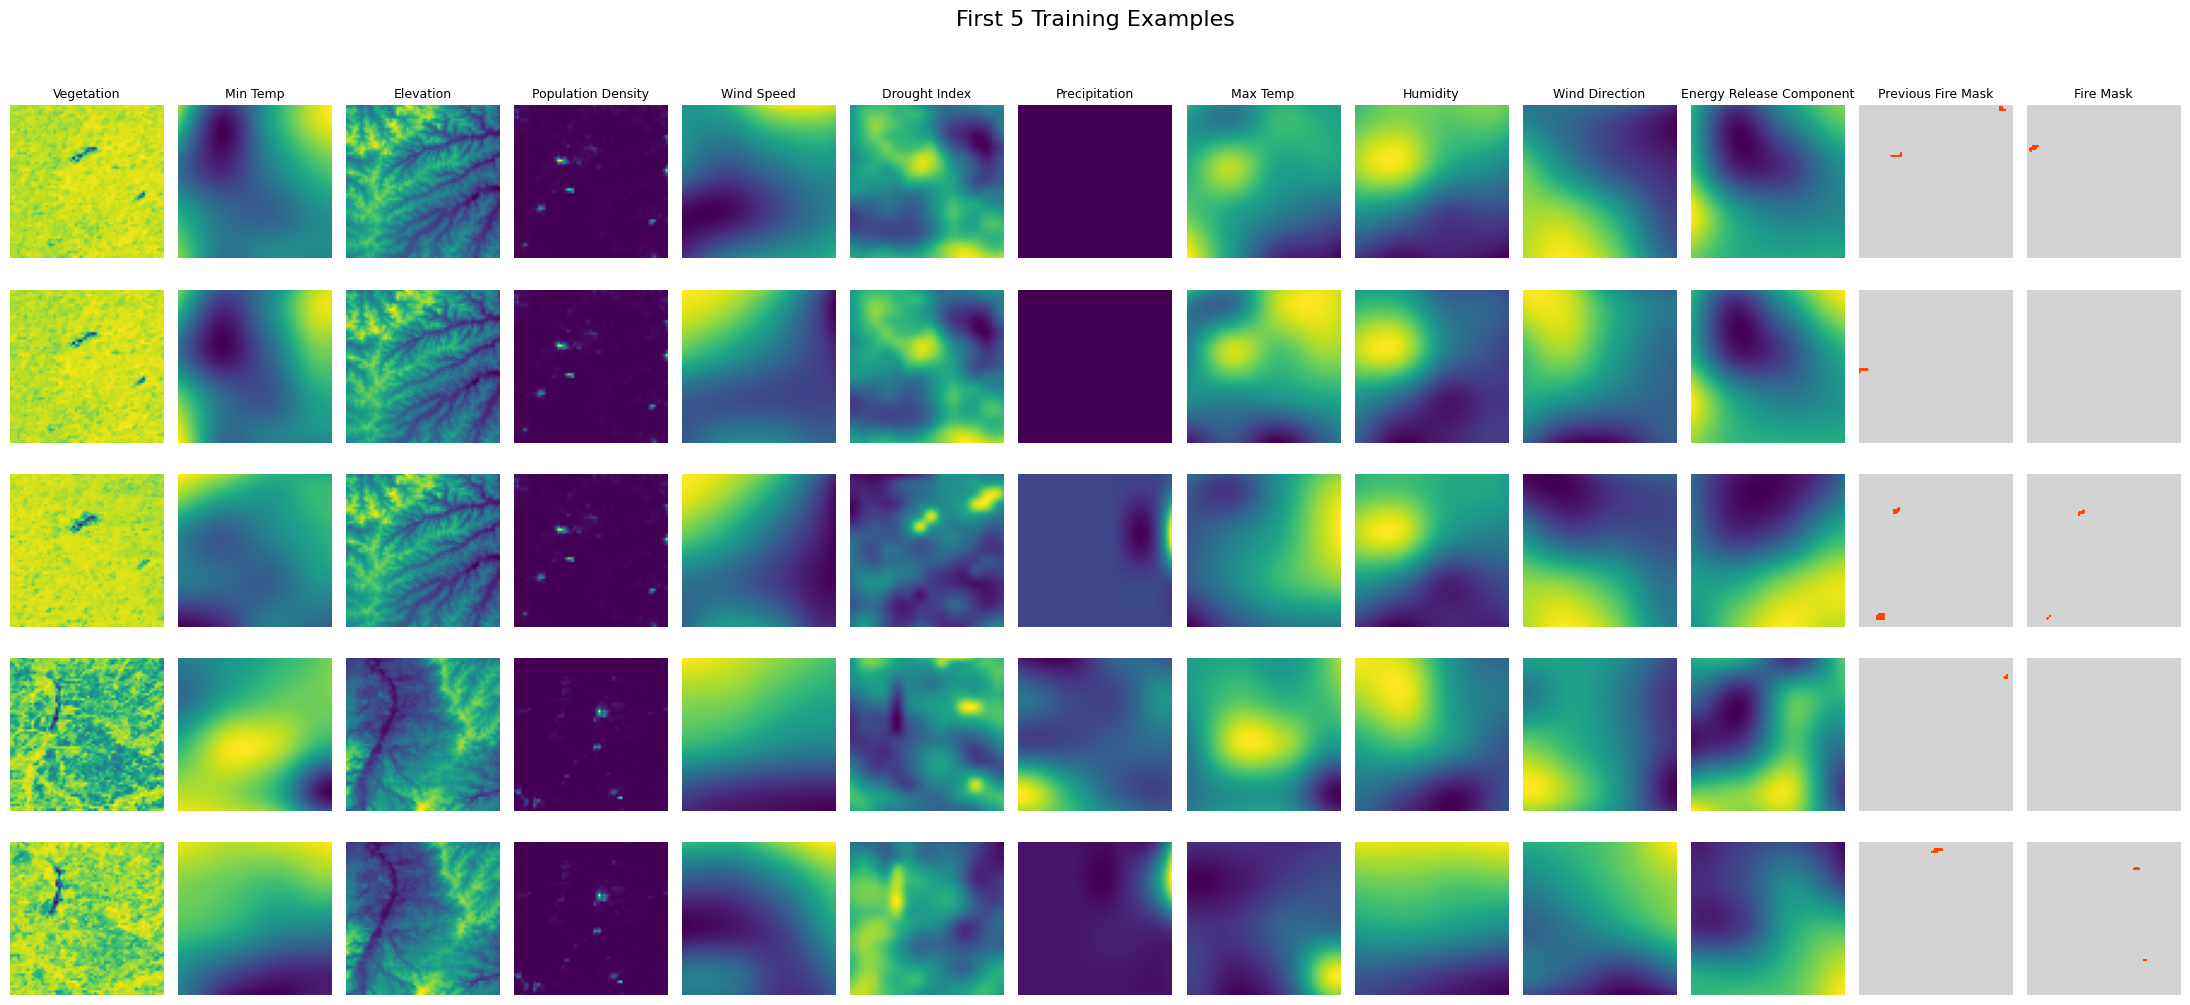

In [10]:
# Plot the first 5 wildfire observations in the training set
# FireMask values:
# 0 = no fire / background
# 1 = fire
# -1 = uncertain / missing / cloud-like areas

fire_cmap = ListedColormap(["black", "lightgray", "orangered"])
fire_norm = BoundaryNorm([-1.5, -0.5, 0.5, 1.5], fire_cmap.N)

feature_names = [
    "Vegetation",
    "Min Temp",
    "Elevation",
    "Population Density",
    "Wind Speed",
    "Drought Index",
    "Precipitation",
    "Max Temp",
    "Humidity",
    "Wind Direction",
    "Previous Fire Mask",
    "Energy Release Component"]

# Plotting order:
# Move Previous Fire Mask to the second-to-last column
plot_order = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 10]

plot_feature_names = [feature_names[i] for i in plot_order]

n_examples = 5
n_features = len(plot_order)

fig, axes = plt.subplots(n_examples,
                         n_features + 1,
                         figsize=(22, 10))

for i in range(n_examples):

    for col, feature_idx in enumerate(plot_order):

        ax = axes[i, col]
        img = X_train[i, :, :, feature_idx]

        if feature_names[feature_idx] == "Previous Fire Mask":
            ax.imshow(img, cmap=fire_cmap, norm=fire_norm)
        else:
            ax.imshow(img, cmap="viridis")

        if i == 0:
            ax.set_title(plot_feature_names[col], fontsize=9)

        ax.axis("off")

    # Plot target Fire Mask in the last column
    ax = axes[i, -1]
    ax.imshow(Y_train[i, :, :, 0], cmap=fire_cmap, norm=fire_norm)

    if i == 0:
        ax.set_title("Fire Mask", fontsize=9)

    ax.axis("off")

plt.suptitle(
    "First 5 Training Examples",
    fontsize=16,
    y=1.02)

plt.tight_layout()
plt.show()

In [11]:
# Store the mean pixel value per feature for each observation in X_train
feature_means = X_train.mean(axis=(1, 2))
feature_means.shape

(14979, 12)

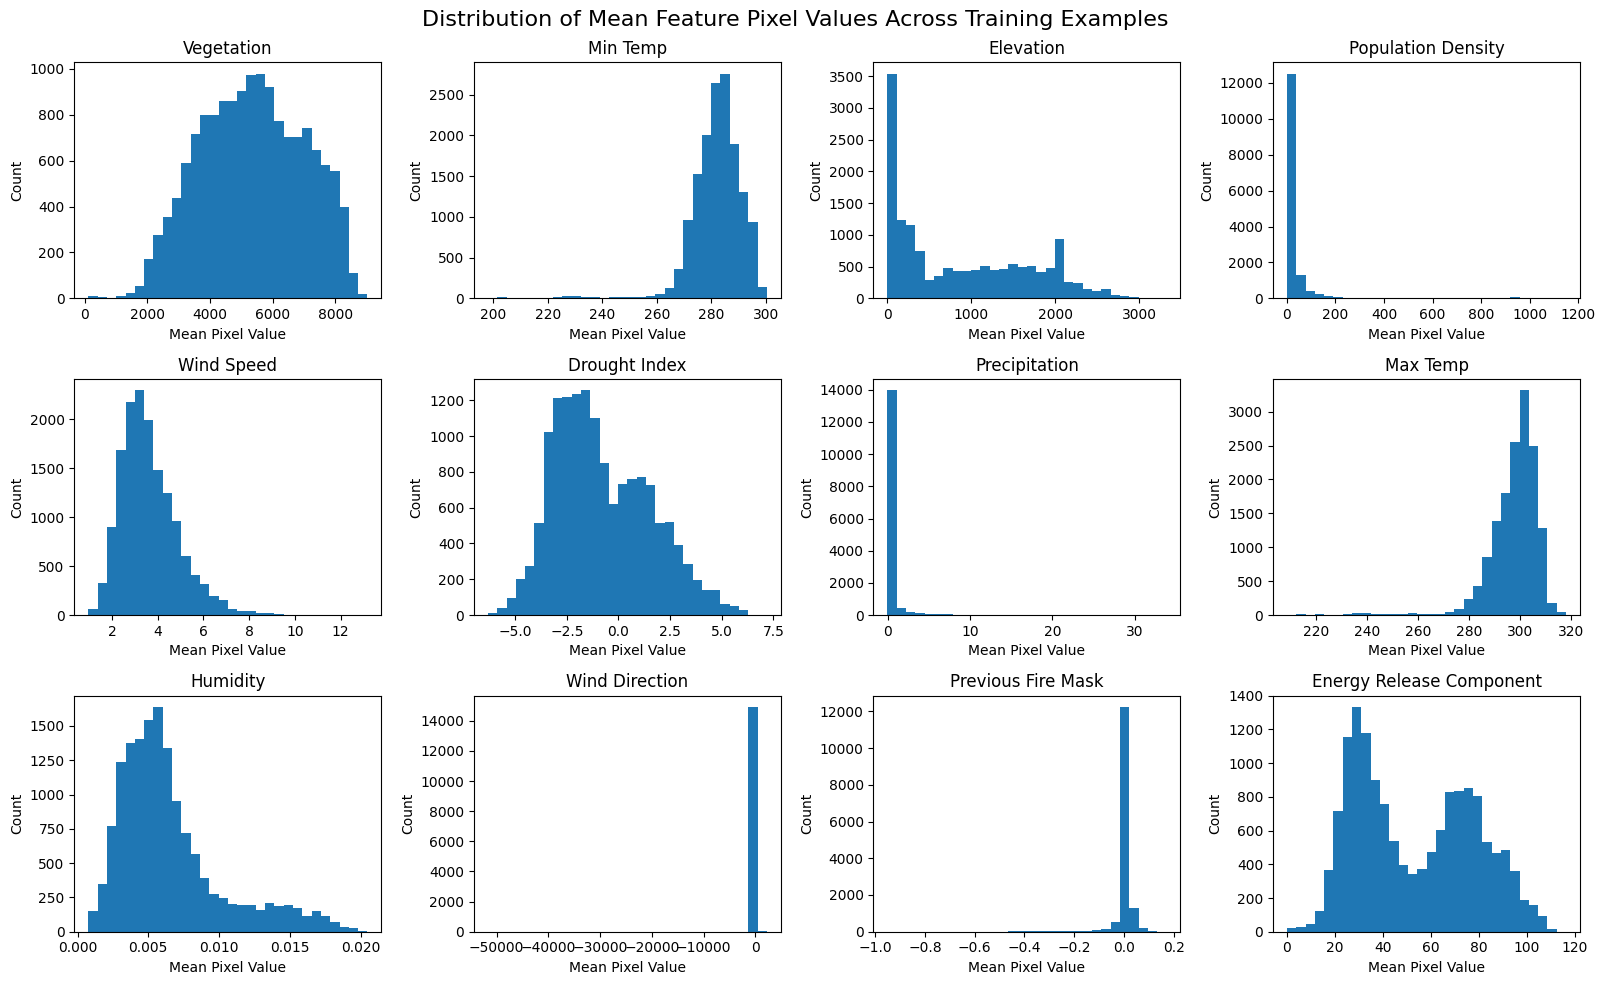

In [12]:
# Plot the distribution of mean pixel values for all the input features
fig, axes = plt.subplots(3, 4, figsize=(16, 10))

axes = axes.flatten()

for i in range(12):

    axes[i].hist(feature_means[:, i],
                 bins=30)

    axes[i].set_title(feature_names[i])
    axes[i].set_xlabel("Mean Pixel Value")
    axes[i].set_ylabel("Count")

plt.suptitle("Distribution of Mean Feature Pixel Values Across Training Examples",
             fontsize=16)

plt.tight_layout()
plt.show()

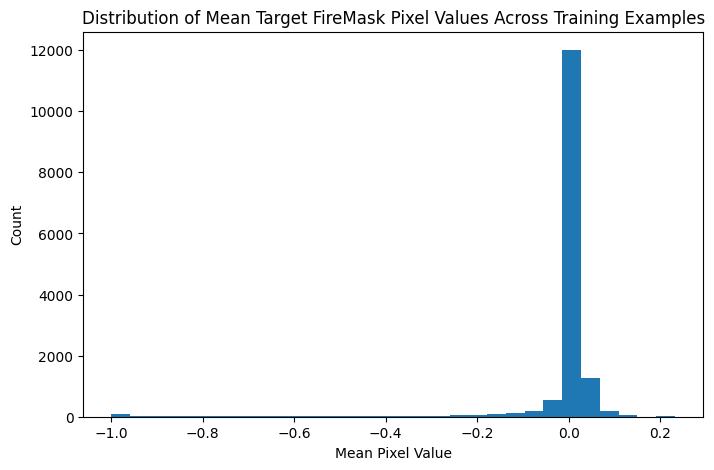

In [13]:
# Plot the distribution of mean pixel values for the target FireMask
firemask_means = Y_train.mean(axis=(1, 2, 3))

plt.figure(figsize=(8, 5))

plt.hist(firemask_means, bins=30)

plt.title("Distribution of Mean Target FireMask Pixel Values Across Training Examples")
plt.xlabel("Mean Pixel Value")
plt.ylabel("Count")

plt.show()

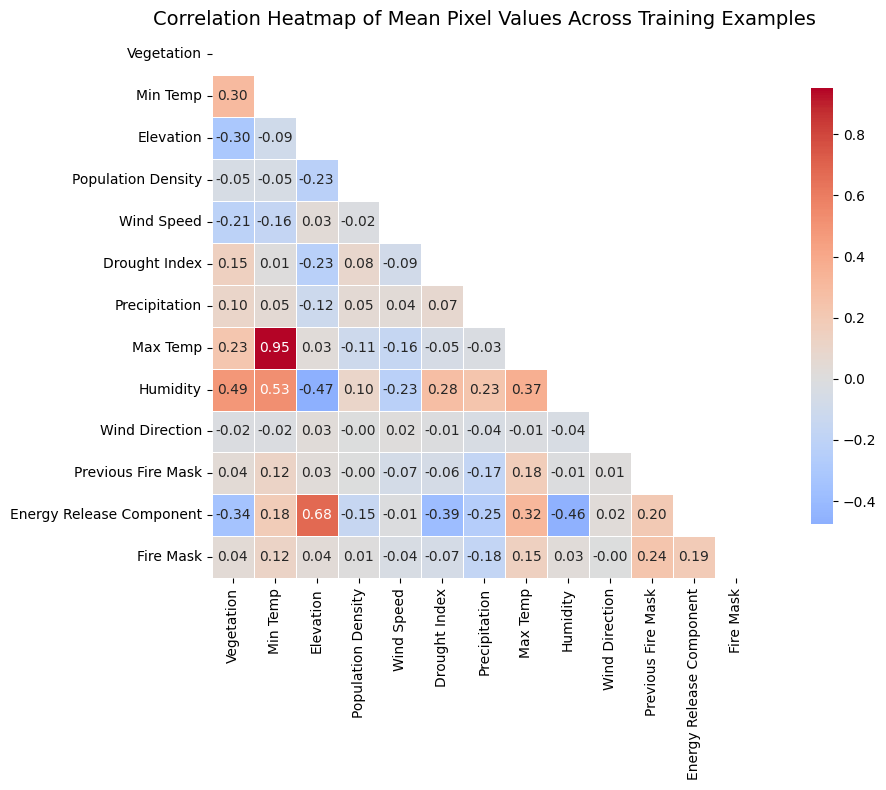

In [14]:
# Store the mean pixel value of each feature for every training observation
feature_mean_pixels = pd.DataFrame(
    feature_means,
    columns=feature_names
)

# Add the mean pixel value of the target FireMask
feature_mean_pixels["Fire Mask"] = firemask_means

# Compute the correlation matrix
correlation_matrix = feature_mean_pixels.corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Plot the correlation heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title(
    "Correlation Heatmap of Mean Pixel Values Across Training Examples",
    fontsize=14
)

plt.tight_layout()
plt.show()

# Data Preprocessing

                     Feature  Mutual Information
10        Previous Fire Mask            0.870719
2                  Elevation            0.660838
11  Energy Release Component            0.630497
3         Population Density            0.552876
9             Wind Direction            0.539166
8                   Humidity            0.538825
7                   Max Temp            0.461507
1                   Min Temp            0.453195
5              Drought Index            0.392930
4                 Wind Speed            0.305807
0                 Vegetation            0.284283
6              Precipitation            0.196777


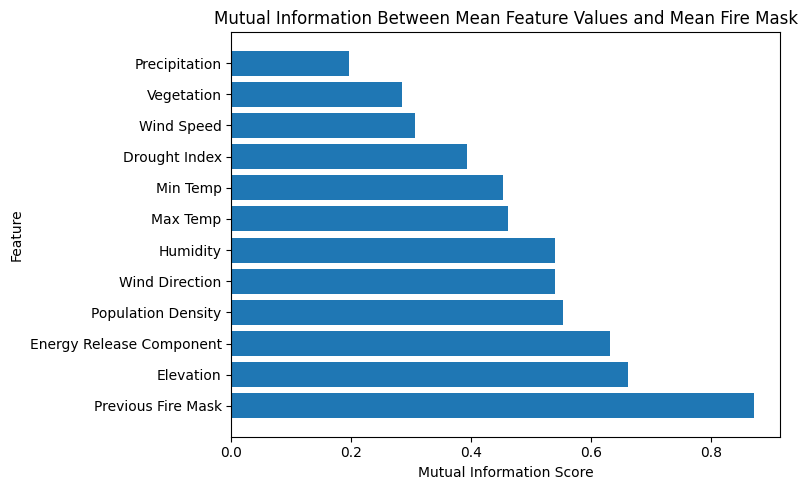

In [15]:
# Compute the mutual information between the mean pixel value of each input feature and the mean pixel value of the target FireMask
# Separate predictors and target
X_summary = feature_mean_pixels.drop(columns="Fire Mask")
y_summary = feature_mean_pixels["Fire Mask"]

# Compute mutual information scores
mi = mutual_info_regression(X_summary,
                            y_summary,
                            random_state=1234)

# Store scores in a DataFrame for easier interpretation
mi_scores = pd.DataFrame({
    "Feature": X_summary.columns,
    "Mutual Information": mi
}).sort_values(by="Mutual Information", ascending=False)

print(mi_scores)

# Plot mutual information scores
plt.figure(figsize=(8, 5))

plt.barh(mi_scores["Feature"],
         mi_scores["Mutual Information"])

plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.title("Mutual Information Between Mean Feature Values and Mean Fire Mask")

plt.tight_layout()
plt.show()

# Choose to retain all features

In [16]:
# Standardize the 11 continuous environmental variables using the training-set mean and standard deviation
# Leave Previous Fire Mask unchanged because it is a discrete spatial mask rather than a continuous variable
# Make copies so the original data remain unchanged
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

# Store the index of Previous Fire Mask
prev_fire_idx = feature_names.index("Previous Fire Mask")

# Loop over each feature
for i in range(len(feature_names)):

    # Skip Previous Fire Mask
    if i == prev_fire_idx:
        continue

    # Compute training statistics
    mean = X_train[:, :, :, i].mean()
    std = X_train[:, :, :, i].std()

    # Prevent division by zero
    if std == 0:
        std = 1

    # Standardize using training statistics
    X_train_scaled[:, :, :, i] = (X_train[:, :, :, i] - mean) / std
    X_val_scaled[:, :, :, i] = (X_val[:, :, :, i] - mean) / std
    X_test_scaled[:, :, :, i] = (X_test[:, :, :, i] - mean) / std

print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled:", X_val_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

print("\nTraining set statistics after scaling:\n")
for i, feature in enumerate(feature_names):

    mean = X_train_scaled[:, :, :, i].mean()
    std = X_train_scaled[:, :, :, i].std()

    print(f"{feature:<30} mean: {mean:.4f}, std: {std:.4f}")

X_train_scaled: (14979, 64, 64, 12)
X_val_scaled: (1877, 64, 64, 12)
X_test_scaled: (1689, 64, 64, 12)

Training set statistics after scaling:

Vegetation                     mean: 0.0000, std: 1.0000
Min Temp                       mean: -0.0000, std: 1.0000
Elevation                      mean: -0.0000, std: 1.0000
Population Density             mean: -0.0000, std: 1.0000
Wind Speed                     mean: 0.0000, std: 1.0000
Drought Index                  mean: -0.0000, std: 1.0000
Precipitation                  mean: -0.0000, std: 1.0000
Max Temp                       mean: 0.0000, std: 1.0000
Humidity                       mean: 0.0000, std: 1.0000
Wind Direction                 mean: 0.0000, std: 1.0000
Previous Fire Mask             mean: -0.0027, std: 0.1383
Energy Release Component       mean: 0.0000, std: 1.0000
